In [9]:
import json
import matplotlib.pyplot as plt
import sys
import numpy as np
plt.rcParams['text.usetex'] = (sys.platform == "darwin")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
plt.rcParams['font.size'] = 9

In [11]:
pde_configs = {
    'schrodinger': {'lb': 0.1, 'ub': 1.0, 'title': r'Schrodinger PDE', 'xlabel_param': r'\kappa'},
    'heat': {'lb': 1e-2, 'ub': 9e-2, 'title': r'Heat PDE', 'xlabel_param': r'\kappa'},
    'fokkerplanck': {'lb': 0.8, 'ub': 1.05, 'title': r'Fokker-Planck PDE', 'xlabel_param': r'\kappa'},
    'poisson2d': {'lb': 1e-2, 'ub': 0.5, 'title': r'2D Poisson PDE', 'xlabel_param': r'\kappa'},
}

data = {}
for type_, _ in pde_configs.items():
    with open(f'./models/pade_pinn_{type_}_error_metrics.json', 'r') as f:
        pade_pinn_metric = json.load(f)
    with open(f'./models/pinn_{type_}_error_metrics.json', 'r') as f:
        pinn_metric = json.load(f)

    pade_pinn_metric = dict(sorted(pade_pinn_metric.items(), key=lambda item: float(item[0])))
    kappa_vals = np.array([float(k) for k in pade_pinn_metric.keys()])

    y_pade_pinn = np.array([err['Rel_MSE'][1] for err in pade_pinn_metric.values()])

    pinn_kappas = np.array([float(k) for k in pinn_metric.keys()])
    pinn_mse = np.array([v['Rel_MSE'] for v in pinn_metric.values()])
    y_pinn = np.array([pinn_mse[np.argmin(np.abs(pinn_kappas - kv))] for kv in kappa_vals])

    unique_kappas, unique_labels = [], []
    last_kv = -float('inf')
    min_dist = (kappa_vals[-1] - kappa_vals[0]) / 20.0
    for kv in kappa_vals:
        if kv - last_kv >= min_dist:
            unique_labels.append(f"{kv:.3f}")
            unique_kappas.append(kv)
            last_kv = kv

    data[type_] = {
        'kappa_vals': kappa_vals,
        'y_pade_pinn': y_pade_pinn,
        'y_pinn': y_pinn,
        'unique_kappas': unique_kappas,
        'unique_labels': unique_labels,
    }

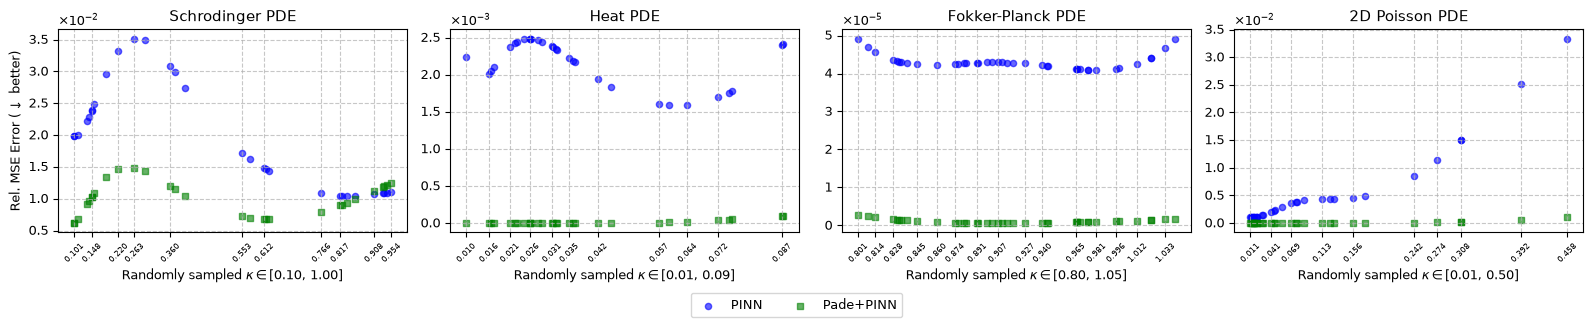

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

handles = None
for ax, (type_, cfg) in zip(axes, pde_configs.items()):
    d = data[type_]
    kappa_vals = d['kappa_vals']
    y_pade_pinn, y_pinn = d['y_pade_pinn'], d['y_pinn']

    h1 = ax.scatter(kappa_vals, y_pinn, label="PINN", color='blue', alpha=0.6, marker='o', s=20)
    h2 = ax.scatter(kappa_vals, y_pade_pinn, label=r"Pade+PINN", color='green', alpha=0.6, marker='s', s=20)
    # fit_pinn = np.polyfit(kappa_vals, np.log10(y_pinn), 3)
    # l1, = ax.plot(kappa_vals, 10**(np.poly1d(fit_pinn)(kappa_vals)), color='blue', linestyle='-', linewidth=1.5)
    # fit_pade_pinn = np.polyfit(kappa_vals, np.log10(y_pade_pinn), 3)
    # l2, = ax.plot(kappa_vals, 10**(np.poly1d(fit_pade_pinn)(kappa_vals)), color='green', linestyle='-', linewidth=1.5)
    if handles is None:
        # handles = [(h1, l1), (h2, l2)]
        labels  = ["PINN", r"Pade+PINN"]

    ax.set_xlabel(fr'Randomly sampled ${cfg["xlabel_param"]} \in [{cfg["lb"]:.2f},\, {cfg["ub"]:.2f}]$')
    ax.set_title(cfg['title'])
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    ax.set_xticks(d['unique_kappas'])
    ax.set_xticklabels(d['unique_labels'], rotation=45, fontsize=6)
    ax.grid(True, which='both', linestyle='--', alpha=0.7)

axes[0].set_ylabel(r'Rel. MSE Error ($\downarrow$ better)')
fig.legend(labels, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.09), frameon=True)
plt.tight_layout()
plt.savefig('./figs/error/padepinn_vs_pinn_error_comparison.pdf', dpi=600, bbox_inches='tight')
plt.show()